
 DUO
📂 Loaded 3073 articles from 2 publishers

 Computing embeddings...
   • Word2Vec (100D, averaged)...
   • FastText (100D, averaged)...
   • Sentence-BERT (384D)...

 Extracting readability & POS features...

 Training with 5-Fold Cross-Validation...

    Word2Vec (Avg)            + Logistic Regression       | Acc: 0.7110 | F1: 0.7018
    Word2Vec (Avg)            + Naive Bayes               | Acc: 0.5916 | F1: 0.5427
    Word2Vec (Avg)            + Support Vector Machines   | Acc: 0.7192 | F1: 0.7097
    Word2Vec (Avg)            + Random Forests            | Acc: 0.6704 | F1: 0.5758
    Word2Vec (Avg)            + K-Nearest Neighbours      | Acc: 0.6521 | F1: 0.5718
    Word2Vec (Avg)            + SGDClassifier             | Acc: 0.6928 | F1: 0.6769
    FastText (Avg)            + Logistic Regression       | Acc: 0.6886 | F1: 0.6761
    FastText (Avg)            + Naive Bayes               | Acc: 0.5841 | F1: 0.5305
    FastText (Avg)            + Support Vector Machines   | Acc

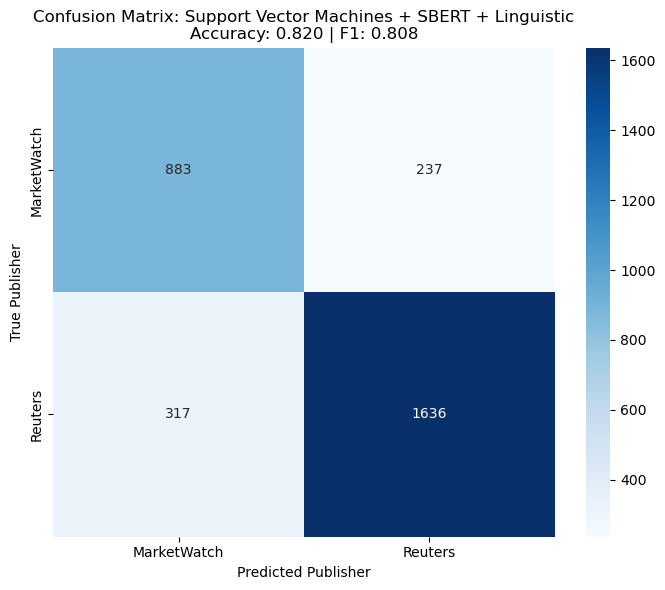


 Full results saved to: march_results_duo.csv
  Confusion matrix saved to: conf_matrix_march_duo.png

 F1 Improvement over Feb Baseline (0.8820): -0.0739

 TRIO
📂 Loaded 2946 articles from 3 publishers

 Computing embeddings...
   • Word2Vec (100D, averaged)...
   • FastText (100D, averaged)...
   • Sentence-BERT (384D)...

 Extracting readability & POS features...

 Training with 5-Fold Cross-Validation...

    Word2Vec (Avg)            + Logistic Regression       | Acc: 0.6171 | F1: 0.6045
    Word2Vec (Avg)            + Naive Bayes               | Acc: 0.4559 | F1: 0.4147
    Word2Vec (Avg)            + Support Vector Machines   | Acc: 0.6378 | F1: 0.6140
    Word2Vec (Avg)            + Random Forests            | Acc: 0.6079 | F1: 0.5510
    Word2Vec (Avg)            + K-Nearest Neighbours      | Acc: 0.5720 | F1: 0.5418
    Word2Vec (Avg)            + SGDClassifier             | Acc: 0.6093 | F1: 0.5847
    FastText (Avg)            + Logistic Regression       | Acc: 0.5903 | F1:

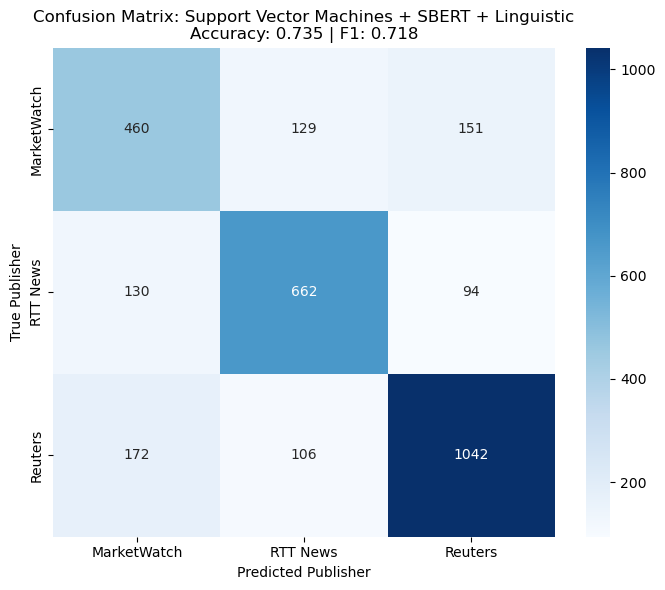


 Full results saved to: march_results_trio.csv
  Confusion matrix saved to: conf_matrix_march_trio.png

 F1 Improvement over Feb Baseline (0.7880): -0.0698


In [6]:
import pandas as pd
import numpy as np
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk import pos_tag
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import GaussianNB  
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.base import clone 
from sentence_transformers import SentenceTransformer
from gensim.models import Word2Vec, FastText
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)


def extract_linguistic_features(texts):
    features = []
    for text in texts:
        sentences = sent_tokenize(text)
        words = word_tokenize(text)
        alpha_words = [w for w in words if w.isalpha()]
        
        if len(alpha_words) == 0:
            features.append([0, 0, 0, 0, 0, 0])
            continue
            
        num_words = len(alpha_words)
        num_sents = max(len(sentences), 1)
        words_per_sent = num_words / num_sents
        ttr = len(set([w.lower() for w in alpha_words])) / num_words
        
        tags = pos_tag(alpha_words)
        pos_counts = {'NN':0, 'VB':0, 'JJ':0, 'RB':0}
        for _, tag in tags:
            if tag.startswith('NN'): pos_counts['NN'] += 1
            elif tag.startswith('VB'): pos_counts['VB'] += 1
            elif tag.startswith('JJ'): pos_counts['JJ'] += 1
            elif tag.startswith('RB'): pos_counts['RB'] += 1
        
        total_pos = sum(pos_counts.values()) + 1e-5
        pos_ratios = [pos_counts[k]/total_pos for k in ['NN', 'VB', 'JJ', 'RB']]
        features.append([words_per_sent, ttr] + pos_ratios)
    return np.array(features)


def get_word2vec_embeddings(texts, vector_size=100):
    tokenized = [word_tokenize(t.lower()) for t in texts]
    model = Word2Vec(tokenized, vector_size=vector_size, window=5, min_count=2, workers=4, epochs=10)
    return np.array([np.mean([model.wv[w] for w in tokens if w in model.wv], axis=0) if any(w in model.wv for w in tokens) else np.zeros(vector_size) for tokens in tokenized])

def get_fasttext_embeddings(texts, vector_size=100):
    tokenized = [word_tokenize(t.lower()) for t in texts]
    model = FastText(tokenized, vector_size=vector_size, window=5, min_count=2, workers=4, epochs=10)
    return np.array([np.mean([model.wv[w] for w in tokens if w in model.wv], axis=0) if any(w in model.wv for w in tokens) else np.zeros(vector_size) for tokens in tokenized])

def get_sbert_embeddings(texts, model_name='all-MiniLM-L6-v2'):
    model = SentenceTransformer(model_name)
    return model.encode(texts, show_progress_bar=False, batch_size=32)


def run_march_experiment(filepath, dataset_name, feb_best_f1):
    print(f"\n{'='*70}")
    print(f" {dataset_name.upper()}")
    print(f"{'='*70}")
    
    df = pd.read_csv(filepath)
    texts = df['TITLE'].values
    labels = df['PUBLISHER'].values
    print(f"📂 Loaded {len(df)} articles from {len(np.unique(labels))} publishers")
    
    print("\n Computing embeddings...")
    print("   • Word2Vec (100D, averaged)...")
    X_w2v = get_word2vec_embeddings(texts)
    
    print("   • FastText (100D, averaged)...")
    X_ft = get_fasttext_embeddings(texts)
    
    print("   • Sentence-BERT (384D)...")
    X_sbert = get_sbert_embeddings(texts)
    
    print("\n Extracting readability & POS features...")
    X_ling = extract_linguistic_features(texts)
    
    feature_sets = {
        'Word2Vec (Avg)': X_w2v,
        'FastText (Avg)': X_ft,
        'Sentence-BERT': X_sbert,
        'SBERT + Linguistic': np.hstack([X_sbert, X_ling]),
        'FastText + Linguistic': np.hstack([X_ft, X_ling]),
        'Word2Vec + Linguistic': np.hstack([X_w2v, X_ling])
    }
    
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
        'Naive Bayes': GaussianNB(), 
        'Support Vector Machines': LinearSVC(random_state=42, max_iter=2000, class_weight='balanced'),
        'Random Forests': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
        'K-Nearest Neighbours': KNeighborsClassifier(n_neighbors=5),
        'SGDClassifier': SGDClassifier(loss='log_loss', random_state=42, max_iter=1000, class_weight='balanced')
    }
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    results = []
    
    print("\n Training with 5-Fold Cross-Validation...\n")
    for feat_name, X_feat in feature_sets.items():
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_feat)
        
        for model_name, model in models.items():
            try:
                cv_acc = cross_val_score(model, X_scaled, labels, cv=cv, scoring='accuracy').mean()
                cv_f1 = cross_val_score(model, X_scaled, labels, cv=cv, scoring='f1_macro').mean()
                
                results.append({
                    'Feature_Set': feat_name,
                    'Model': model_name,
                    'CV_Accuracy': cv_acc,
                    'CV_F1_Macro': cv_f1
                })
                print(f"    {feat_name:<25} + {model_name:<25} | Acc: {cv_acc:.4f} | F1: {cv_f1:.4f}")
            except Exception as e:
                print(f"   ⚠️ {feat_name} + {model_name} failed: {e}")
    
    res_df = pd.DataFrame(results)
    
    print(f"\n🏆 TOP 3 MODELS BY ACCURACY ({dataset_name.upper()})")
    top3_acc = res_df.nlargest(3, 'CV_Accuracy')[['Model', 'Feature_Set', 'CV_Accuracy', 'CV_F1_Macro']]
    print(top3_acc.to_string(index=False))
    
    print(f"\n🏆 TOP 3 MODELS BY F1-SCORE ({dataset_name.upper()})")
    top3_f1 = res_df.nlargest(3, 'CV_F1_Macro')[['Model', 'Feature_Set', 'CV_Accuracy', 'CV_F1_Macro']]
    print(top3_f1.to_string(index=False))
    
    best_idx = res_df['CV_F1_Macro'].idxmax()
    best = res_df.iloc[best_idx]
    best_feat = feature_sets[best['Feature_Set']]
    best_model = clone(models[best['Model']])  
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(best_feat)
    
    y_pred_cv = cross_val_predict(best_model, X_scaled, labels, cv=cv)
    labels_unique = sorted(np.unique(labels))
    cm = confusion_matrix(labels, y_pred_cv, labels=labels_unique)
    
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_unique, yticklabels=labels_unique)
    plt.title(f'Confusion Matrix: {best["Model"]} + {best["Feature_Set"]}\nAccuracy: {best["CV_Accuracy"]:.3f} | F1: {best["CV_F1_Macro"]:.3f}')
    plt.ylabel('True Publisher')
    plt.xlabel('Predicted Publisher')
    plt.tight_layout()
    plt.savefig(f'conf_matrix_march_{dataset_name}.png', dpi=300)
    plt.show()
    
    res_df.to_csv(f'march_results_{dataset_name}.csv', index=False)
    print(f"\n Full results saved to: march_results_{dataset_name}.csv")
    print(f"  Confusion matrix saved to: conf_matrix_march_{dataset_name}.png")
    
    improvement = best['CV_F1_Macro'] - feb_best_f1
    print(f"\n F1 Improvement over Feb Baseline ({feb_best_f1:.4f}): {improvement:+.4f}")
    
    return res_df


duo_results = run_march_experiment('clean_duo_data.csv', 'duo', feb_best_f1=0.882)
trio_results = run_march_experiment('clean_trio_data.csv', 'trio', feb_best_f1=0.788)